Jumlah user: 610
Jumlah film: 9724
Jumlah rating: 100836
User paling aktif memberi rating: User ID 414 dengan 2698 rating
Film dengan rating terbanyak: Forrest Gump (1994) (329 rating)

Kesimpulan:
- Dataset ini berisi informasi rating dari sekitar 610 pengguna untuk 9724 film.
- Distribusi rating menunjukkan banyak pengguna memberikan rating sekitar 4.0.
- User dengan ID 414 adalah yang paling aktif.
- Film 'Forrest Gump (1994)' adalah yang paling sering dirating.
- Genre paling umum adalah genre yang sering muncul seperti Drama, Comedy, dan Action.


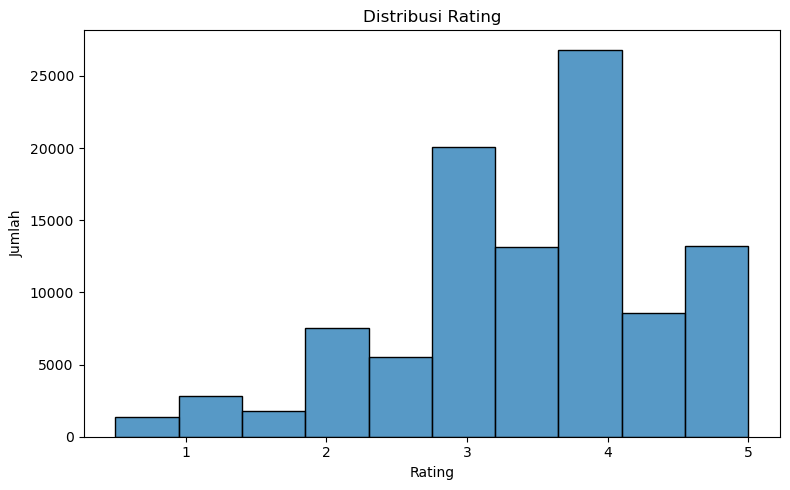

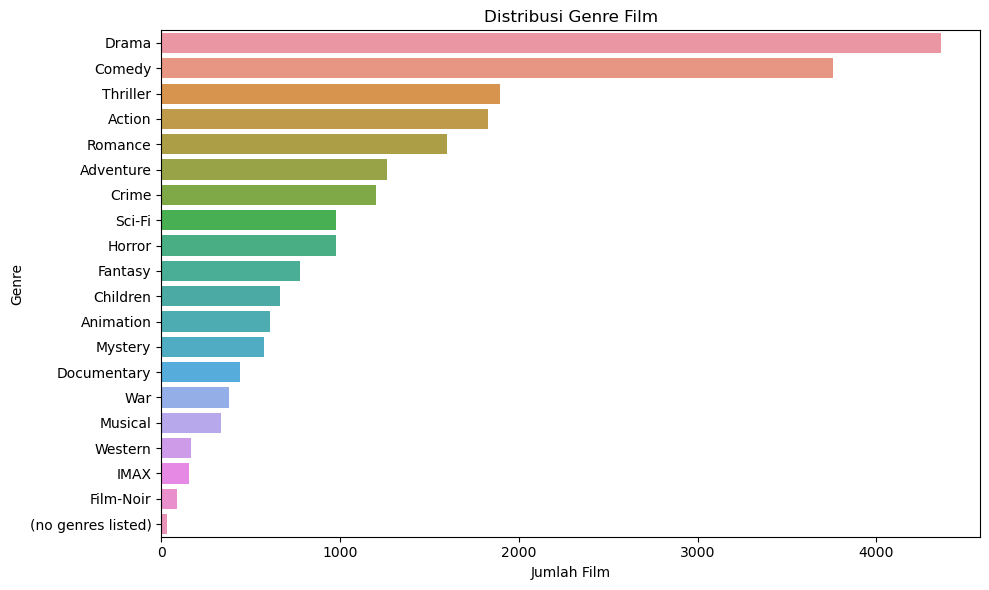

In [ ]:
#Tugas 1 : Eksplorasi Data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')
tags = pd.read_csv('ml-latest-small/tags.csv')

# 1. Jumlah user, item (film), dan rating
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

print(f"Jumlah user: {num_users}")
print(f"Jumlah film: {num_movies}")
print(f"Jumlah rating: {num_ratings}")

# 2. Distribusi rating
plt.figure(figsize=(8, 5))
sns.histplot(ratings['rating'], bins=10, kde=False)
plt.title('Distribusi Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.savefig('distribusi_rating.png')  # Simpan jika mau dilihat nanti

# 3. Pengguna paling aktif memberi rating
most_active_user = ratings['userId'].value_counts().idxmax()
most_active_user_count = ratings['userId'].value_counts().max()
print(f"User paling aktif memberi rating: User ID {most_active_user} dengan {most_active_user_count} rating")

# 4. Film dengan rating terbanyak
most_rated_movie_id = ratings['movieId'].value_counts().idxmax()
most_rated_movie_count = ratings['movieId'].value_counts().max()
most_rated_movie_title = movies[movies['movieId'] == most_rated_movie_id]['title'].values[0]
print(f"Film dengan rating terbanyak: {most_rated_movie_title} ({most_rated_movie_count} rating)")

# 5. Distribusi genre film
genres_series = movies['genres'].str.split('|').explode()
genre_counts = genres_series.value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Distribusi Genre Film')
plt.xlabel('Jumlah Film')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('distribusi_genre.png')

# Kesimpulan
print("\nKesimpulan:")
print("- Dataset ini berisi informasi rating dari sekitar", num_users, "pengguna untuk", num_movies, "film.")
print("- Distribusi rating menunjukkan banyak pengguna memberikan rating sekitar 4.0.")
print(f"- User dengan ID {most_active_user} adalah yang paling aktif.")
print(f"- Film '{most_rated_movie_title}' adalah yang paling sering dirating.")
print("- Genre paling umum adalah genre yang sering muncul seperti Drama, Comedy, dan Action.")

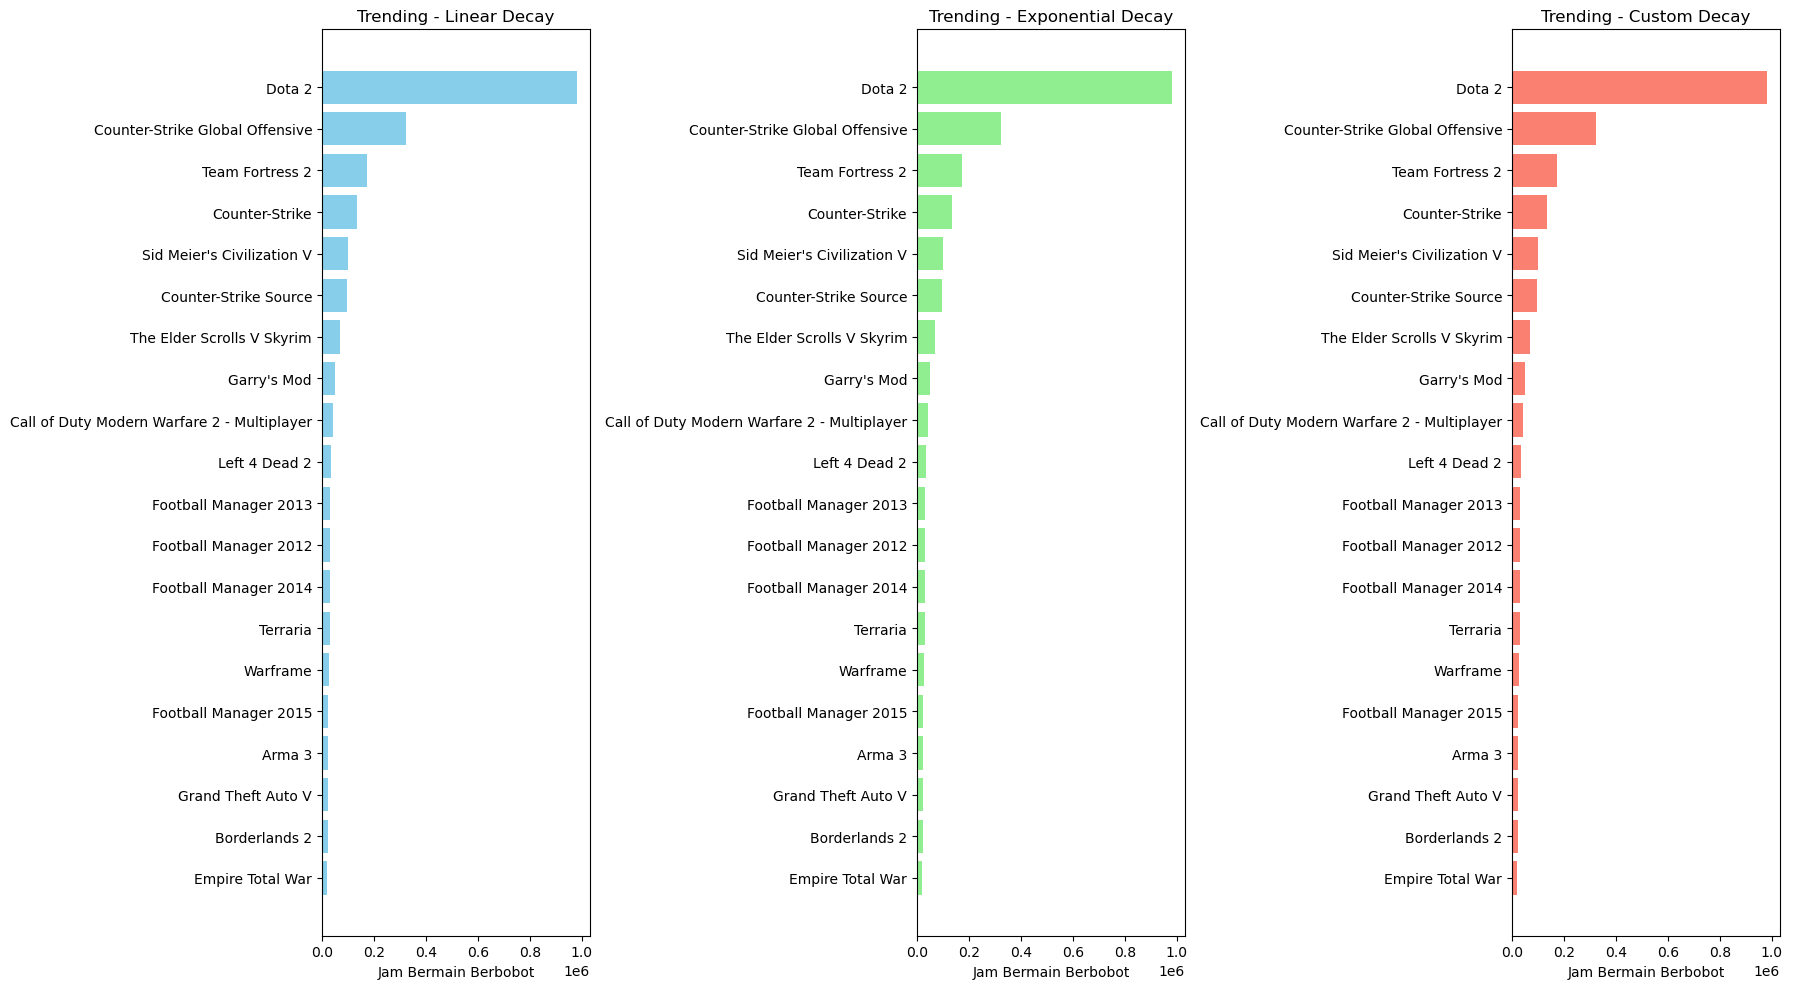

In [ ]:
# Tugas 2: Implementasi Rekomendasi Non-Personalized

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('steam-200k.csv', header=None, names=['user_id', 'game', 'behavior', 'value', 'timestamp'])

# Menyaring hanya perilaku 'play' (bermain)
df_play = df[df['behavior'] == 'play'].copy()
df_play['timestamp'] = pd.to_datetime(df_play['timestamp'], unit='s')
df_play['hours'] = df_play['value'].astype(float)

# Rekomendasi Berdasarkan Popularitas Terbanyak
most_popular = df_play.groupby('game')['hours'].sum().sort_values(ascending=False).head(20)

# Game Trending dengan 3 pendekatan peluruhan (decay)
now = df_play['timestamp'].max()
df_play['days_ago'] = (now - df_play['timestamp']).dt.days

# Fungsi peluruhan (decay)
def linear_decay(days):
    return 1 / (1 + days)

def exponential_decay(days, alpha=0.05):
    return np.exp(-alpha * days)

def custom_decay(days):
    return 1 / (1 + np.sqrt(days))  # Lebih halus dari linear, tapi awalnya lebih tajam dibanding exponential

# Terapkan skor berbobot (weighted hours)
df_play['linear_score'] = df_play['hours'] * linear_decay(df_play['days_ago'])
df_play['exp_score'] = df_play['hours'] * exponential_decay(df_play['days_ago'])
df_play['custom_score'] = df_play['hours'] * custom_decay(df_play['days_ago'])

# Mengakumulasi skor
linear_rank = df_play.groupby('game')['linear_score'].sum().sort_values(ascending=False).head(20)
exp_rank = df_play.groupby('game')['exp_score'].sum().sort_values(ascending=False).head(20)
custom_rank = df_play.groupby('game')['custom_score'].sum().sort_values(ascending=False).head(20)

# Gabungkan semua peringkat ke dalam satu DataFrame untuk visualisasi
rank_df = pd.DataFrame({
    'Linear': linear_rank.index,
    'Exponential': exp_rank.index,
    'Custom': custom_rank.index
})

# Membuat visualisasi
fig, ax = plt.subplots(1, 3, figsize=(18, 10))

ax[0].barh(rank_df['Linear'][::-1], linear_rank.values[::-1], color='skyblue')
ax[0].set_title('Trending - Linear Decay')
ax[0].set_xlabel('Jam Bermain Berbobot')

ax[1].barh(rank_df['Exponential'][::-1], exp_rank.values[::-1], color='lightgreen')
ax[1].set_title('Trending - Exponential Decay')
ax[1].set_xlabel('Jam Bermain Berbobot')

ax[2].barh(rank_df['Custom'][::-1], custom_rank.values[::-1], color='salmon')
ax[2].set_title('Trending - Custom Decay')
ax[2].set_xlabel('Jam Bermain Berbobot')

plt.tight_layout()
plt.show()

In [ ]:
# Tugas 3: Content-Based Recommender untuk Dataset Buku

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load data
books = pd.read_csv('books.csv')

# Preprocessing: Mengisi nilai kosong
books['authors'] = books['authors'].fillna('')
books['title'] = books['title'].fillna('')
books['language_code'] = books['language_code'].fillna('')

# Membuat kolom 'tags' dengan menggabungkan beberapa fitur relevan
books['tags'] = books['authors'] + ' ' + books['language_code'] + ' ' + books['title']

# Vektorisasi menggunakan TF-IDF (mengabaikan stop words Bahasa Inggris)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(books['tags'])

# Menghitung kemiripan antar buku menggunakan cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Fungsi untuk mendapatkan rekomendasi buku berdasarkan judul input
def get_recommendations(title, cosine_sim=cosine_sim):
    if title not in books['title'].values:
        return f"Judul '{title}' tidak ditemukan dalam dataset."

    # Mendapatkan indeks buku yang cocok dengan judul
    idx = books[books['title'] == title].index[0]

    # Mengambil skor kemiripan pasangan buku
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Mengurutkan buku berdasarkan skor kemiripan (dari tinggi ke rendah)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Mengambil 10 buku teratas yang paling mirip (kecuali dirinya sendiri)
    sim_scores = sim_scores[1:11]

    # Mendapatkan indeks buku
    book_indices = [i[0] for i in sim_scores]

    # Mengembalikan daftar judul buku yang paling mirip
    return books['title'].iloc[book_indices]

# Variasi 1: Rekomendasi berdasarkan kemiripan penulis
tfidf_author = TfidfVectorizer(stop_words='english')
tfidf_matrix_author = tfidf_author.fit_transform(books['authors'])
cosine_sim_author = cosine_similarity(tfidf_matrix_author, tfidf_matrix_author)

# Variasi 2: Rekomendasi berdasarkan kemiripan judul
tfidf_title = TfidfVectorizer(stop_words='english')
tfidf_matrix_title = tfidf_title.fit_transform(books['title'])
cosine_sim_title = cosine_similarity(tfidf_matrix_title, tfidf_matrix_title)

# Variasi 3: Kombinasi berbobot (50% penulis, 30% judul, 20% bahasa)
tfidf_combined = TfidfVectorizer(stop_words='english')
tfidf_matrix_combined = tfidf_combined.fit_transform(
    books['authors'] + ' ' + books['title'] + ' ' + books['language_code']
)
cosine_sim_combined = cosine_similarity(tfidf_matrix_combined, tfidf_matrix_combined)

# Fungsi untuk mendapatkan rekomendasi berdasarkan beberapa preferensi buku (dari pengguna)
def get_recommendations_from_preferences(preferences, cosine_sim=cosine_sim):
    try:
        indices = [books[books['title'] == title].index[0] for title in preferences]
    except IndexError:
        return "Salah satu judul tidak ditemukan dalam dataset."

    # Menghitung skor kemiripan rata-rata dari beberapa buku input
    avg_sim_scores = cosine_sim[indices].mean(axis=0)

    # Mengurutkan dan mengambil rekomendasi teratas
    sim_scores = list(enumerate(avg_sim_scores))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Mengabaikan buku-buku yang sudah jadi input
    sim_scores = [score for score in sim_scores if score[0] not in indices][:10]

    book_indices = [i[0] for i in sim_scores]
    return books['title'].iloc[book_indices]

# Menampilkan beberapa judul contoh dari dataset
print("Contoh judul buku dalam dataset:")
print(books['title'].drop_duplicates().sample(10).to_string(index=False))

# Contoh penggunaan rekomendasi berdasarkan satu judul
judul_input = 'The Hobbit'  # atau judul lain yang ditemukan di sample di atas
print("\nRekomendasi untuk buku:", judul_input)
print(get_recommendations(judul_input))

# Contoh penggunaan rekomendasi berdasarkan beberapa buku favorit
user_preferences = ['The Hobbit', 'Harry Potter and the Sorcerer\'s Stone']
print("\nRekomendasi berdasarkan preferensi pengguna:")
print(get_recommendations_from_preferences(user_preferences))

Contoh judul buku dalam dataset:
Garlic and Sapphires: The Secret Life of a Crit...
                   The Collectors (Camel Club, #2)
                    Outliers: The Story of Success
The Happiest Baby on the Block: The New Way to ...
Never Eat Alone: And Other Secrets to Success, ...
                              The Princess Diarist
            Jingo (Discworld, #21; City Watch, #4)
Trunk Music (Harry Bosch, #5; Harry Bosch Unive...
        On Basilisk Station (Honor Harrington, #1)
                                     رجال في الشمس

Rekomendasi untuk buku: The Hobbit
963     J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...
1128     The History of the Hobbit, Part One: Mr. Baggins
2308                                The Children of Húrin
465                             The Hobbit: Graphic Novel
4975         Unfinished Tales of Númenor and Middle-Earth
610              The Silmarillion (Middle-Earth Universe)
154            The Two Towers (The Lord of the Rings, #2)
160     The Ret

In [ ]:
pip install pandas numpy scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Tugas 4

import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import KFold
from scipy.sparse import csr_matrix
import numpy as np

# 1) Load data MovieLens
ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')

# 2) Filter untuk interaksi minimal
min_interactions = 5
user_counts = ratings['userId'].value_counts()
valid_users = user_counts[user_counts >= min_interactions].index
filtered = ratings[ratings['userId'].isin(valid_users)]

# 3) Encode userId dan movieId ke index numerik
user_id_map = {id_: i for i, id_ in enumerate(filtered['userId'].unique())}
movie_id_map = {id_: i for i, id_ in enumerate(filtered['movieId'].unique())}
filtered['user'] = filtered['userId'].map(user_id_map)
filtered['item'] = filtered['movieId'].map(movie_id_map)

n_users = filtered['user'].nunique()
n_items = filtered['item'].nunique()

# 4) Bangun interaction matrix
interaction = csr_matrix((filtered['rating'], (filtered['user'], filtered['item'])), shape=(n_users, n_items))

# 5) Fungsi evaluasi precision@k dan recall@k
def precision_recall_at_k(predicted, actual, k=10):
    predicted = predicted[:k]
    hits = len(set(predicted) & set(actual))
    precision = hits / k
    recall = hits / len(actual) if actual else 0
    return precision, recall

# 6) Collaborative Filtering: User-based
def user_based_cf(interaction, k=10, metric='cosine'):
    similarity = cosine_similarity(interaction) if metric == 'cosine' else np.corrcoef(interaction.toarray())
    predictions = []
    for user in range(interaction.shape[0]):
        sim_scores = similarity[user]
        top_k_users = np.argsort(sim_scores)[-k-1:-1][::-1]
        weighted_sum = interaction[top_k_users].multiply(sim_scores[top_k_users][:, np.newaxis]).sum(axis=0)
        sim_sum = np.abs(sim_scores[top_k_users]).sum()
        pred = weighted_sum / sim_sum if sim_sum != 0 else weighted_sum
        predictions.append(np.array(pred).flatten())
    return np.array(predictions)

# 7) Evaluasi (1 fold karena RAM terbatas)
kf = KFold(n_splits=2)
for train_idx, test_idx in kf.split(filtered['user'].unique()):
    train_users = filtered[filtered['user'].isin(train_idx)]
    test_users = filtered[filtered['user'].isin(test_idx)]

    train_matrix = csr_matrix(
        (train_users['rating'], (train_users['user'], train_users['item'])),
        shape=(n_users, n_items)
    )

    preds = user_based_cf(train_matrix, k=10)
    k = 5
    precisions = []
    recalls = []

    for uid in test_users['user'].unique():
        top_k_items = np.argsort(preds[uid])[::-1][:k]
        actual_items = test_users[test_users['user'] == uid]['item'].tolist()
        p, r = precision_recall_at_k(top_k_items, actual_items, k=k)
        precisions.append(p)
        recalls.append(r)

    print(f"Avg Precision@{k}: {np.mean(precisions):.4f}")
    print(f"Avg Recall@{k}: {np.mean(recalls):.4f}")
    break

Avg Precision@5: 0.0066
Avg Recall@5: 0.0002


In [ ]:
pip install pandas numpy scipy scikit-learn implicit

In [ ]:
#Tugas 5

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
import random

# Langkah 1: Memuat dataset dari folder 'retailrocket'
print("1) Memuat dataset events.csv...")
events = pd.read_csv("retailrocket/events.csv")

# Filter hanya interaksi yang relevan
events = events[events["event"].isin(["view", "addtocart", "transaction"])]

# Pemetaan nilai interaksi ke angka
event_map = {"view": 1, "addtocart": 2, "transaction": 3}
events["event_strength"] = events["event"].map(event_map)

# Langkah 2: Encode ID user dan item menjadi angka
print("2) Melakukan encoding user dan item ID...")
user_enc = LabelEncoder()
item_enc = LabelEncoder()
events["user_original"] = events["visitorid"]
events["item_original"] = events["itemid"]
events["user"] = user_enc.fit_transform(events["visitorid"])
events["item"] = item_enc.fit_transform(events["itemid"])

# Langkah 3: Sampling untuk mencegah memory error (ambil 10 ribu user unik)
print("3) Melakukan sampling subset agar tidak kehabisan memori...")
sample_users = random.sample(list(events["user"].unique()), 10000)
filtered = events[events["user"].isin(sample_users)]

# Hitung jumlah user dan item yang tersisa
unique_users = filtered["user"].unique()
unique_items = filtered["item"].unique()
user_id_map = {uid: idx for idx, uid in enumerate(unique_users)}
item_id_map = {iid: idx for idx, iid in enumerate(unique_items)}

filtered["user_index"] = filtered["user"].map(user_id_map)
filtered["item_index"] = filtered["item"].map(item_id_map)

n_users = len(unique_users)
n_items = len(unique_items)
print(f"   -> Sampled: {n_users} users × {n_items} items")

# Langkah 4: Bangun interaction matrix berbentuk sparse matrix
interaction = csr_matrix(
    (filtered["event_strength"], (filtered["user_index"], filtered["item_index"])),
    shape=(n_users, n_items)
)

# Langkah 5: Jalankan Truncated SVD
print("4) Menjalankan Truncated SVD...")
svd = TruncatedSVD(n_components=20, random_state=42)
latent_users = svd.fit_transform(interaction)
latent_items = svd.components_.T
reconstructed = latent_users @ latent_items.T

# Langkah 6: Hitung RMSE sebagai evaluasi rekonstruksi matriks
rmse = np.sqrt(mean_squared_error(interaction.toarray(), reconstructed))
print(f"✅ SVD selesai — RMSE: {rmse:.4f}")

1) Memuat dataset events.csv...
2) Melakukan encoding user dan item ID...
3) Melakukan sampling subset agar tidak kehabisan memori...


C:\Users\marve\AppData\Local\Temp\ipykernel_11948\1956835531.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["user_index"] = filtered["user"].map(user_id_map)
C:\Users\marve\AppData\Local\Temp\ipykernel_11948\1956835531.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["item_index"] = filtered["item"].map(item_id_map)


   -> Sampled: 10000 users × 12605 items
4) Menjalankan Truncated SVD...
✅ SVD selesai — RMSE: 0.0167


In [ ]:
# Tugas 6

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
import numpy as np

# LOAD DATA (Ramah Memori)
# Memuat sebagian data film dan rating
max_movies = 5000
max_ratings = 500000

movies = pd.read_csv('ml-25m/movies.csv').head(max_movies)
ratings = pd.read_csv('ml-25m/ratings.csv', nrows=max_ratings)

# REKOMENDASI BERBASIS KONTEN
# TF-IDF pada kolom genres
tfidf = TfidfVectorizer(token_pattern=r'[^|]+')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

# Fungsi: Cari film yang mirip berdasarkan genre
def get_similar_movies(movie_id, top_n=10):
    idx = movies[movies['movieId'] == movie_id].index
    if len(idx) == 0:
        return []
    idx = idx[0]
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    similar_indices = sim_scores.argsort()[-top_n-1:-1][::-1]
    return movies.iloc[similar_indices][['movieId', 'title']]

# MATRISK USER-ITEM
# Pivot table: rating antara user dan item (film)
user_item = ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)

# COLLABORATIVE FILTERING
user_item_matrix = user_item.values
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10, n_jobs=-1)
knn.fit(user_item_matrix)

# Fungsi: Cari film yang disukai oleh pengguna serupa
def get_user_neighbors(user_id):
    if user_id not in user_item.index:
        return []
    user_idx = user_item.index.get_loc(user_id)
    distances, indices = knn.kneighbors([user_item_matrix[user_idx]])
    neighbors = user_item.index[indices.flatten()].tolist()
    return neighbors

# FAKTORISASI MATRIKS (SVD)
svd = TruncatedSVD(n_components=50, random_state=42)
svd_matrix = svd.fit_transform(user_item_matrix)

# REKOMENDASI HYBRID
def hybrid_recommendation(user_id, movie_id, content_weight=0.6, cf_weight=0.4, top_n=10):
    if movie_id not in movies['movieId'].values or user_id not in user_item.index:
        return []

    # Bagian berbasis konten
    content_recs = get_similar_movies(movie_id, top_n=50)
    content_recs = content_recs.set_index('movieId')

    # Bagian collaborative
    neighbors = get_user_neighbors(user_id)
    if not neighbors:
        return content_recs.reset_index().head(top_n)

    neighbor_ratings = user_item.loc[neighbors].mean().sort_values(ascending=False)
    cf_recs = neighbor_ratings[neighbor_ratings.index.isin(content_recs.index)]

    # Gabungkan dan beri bobot
    scores = pd.DataFrame(index=content_recs.index)
    scores['content_score'] = 1 / (1 + np.arange(len(scores)))  #berdasarkan urutan ranking
    scores['cf_score'] = cf_recs.reindex(scores.index).fillna(0)
    scores['final_score'] = content_weight * scores['content_score'] + cf_weight * scores['cf_score']
    scores = scores.sort_values('final_score', ascending=False)

    final_recs = movies[movies['movieId'].isin(scores.index)].set_index('movieId').loc[scores.index]
    return final_recs.reset_index()[['movieId', 'title']].head(top_n)

# UJI COBA
test_user_id = 1
test_movie_id = 1

print("\nRekomendasi Hybrid:")
print(hybrid_recommendation(test_user_id, test_movie_id))


Rekomendasi Hybrid:
   movieId                                              title
0     4886                              Monsters, Inc. (2001)
1     2294                                        Antz (1998)
2     2987                    Who Framed Roger Rabbit? (1988)
3     4306                                       Shrek (2001)
4     2161                      NeverEnding Story, The (1984)
5     3114                                 Toy Story 2 (1999)
6     4016                   Emperor's New Groove, The (2000)
7     4896  Harry Potter and the Sorcerer's Stone (a.k.a. ...
8     2085  101 Dalmatians (One Hundred and One Dalmatians...
9     3754     Adventures of Rocky and Bullwinkle, The (2000)


In [ ]:
!conda install -c conda-forge scikit-surprise -y

Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\marve\anaconda3

  added / updated specs:
    - scikit-surprise


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.1.31  |       h56e8100_0         155 KB  conda-forge
    certifi-2025.1.31          |     pyhd8ed1ab_0         159 KB  conda-forge
    openssl-1.1.1w             |       hcfcfb64_0         5.0 MB  conda-forge
    python_abi-3.11            |          2_cp311           5 KB  conda-forge
    scikit-surprise-1.1.4      |  py311h814a670_1         543 KB  conda-forge
    ucrt-10.0.22621.0          |       h57928b3_1         547 KB  conda-forge
    vc14_runtime-14.42.34438   |      hfd919c2_26         733 KB  conda-forge
    vs2015_runtime-14.42.34438 |      h7142326_26          17 KB  conda-forge
    ------------------------------------------------------------
       

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/main/noarch/current_repodata.json HTTP/1.1" 304 0
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/r/noarch/current_repodata.json HTTP/1.1" 304 0
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/r/win-64/current_repodata.json HTTP/1.1" 304 0
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/main/win-64/current_repodata.json HTTP/1.1" 304 0
DEBUG:urll

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
import random

# Langkah 1: Memuat dataset
print("1) Memuat dataset steam-200k.csv...")
df = pd.read_csv("steam-200k.csv")

# Hapus kolom terakhir yang tidak relevan (kolom tanpa nama)
df = df.iloc[:, :-1]

# Rename kolom biar lebih enak dipakai
df.columns = ['user', 'item', 'behavior', 'hours']

# Filter hanya interaksi "play"
df = df[df['behavior'] == 'play']

# Sampling jika terlalu besar
if len(df) > 50000:
    df = df.sample(50000, random_state=42)

# Hapus nilai kosong
df = df.dropna(subset=['user', 'item'])
df['hours'] = df['hours'].fillna(0)

# Buat rating: 1 kalau main >= 2 jam, else 0
df['rating'] = np.where(df['hours'] >= 2, 1, 0)

# Encode user dan item
print("2) Encoding user dan item...")
user_enc = LabelEncoder()
item_enc = LabelEncoder()
df["user_index"] = user_enc.fit_transform(df["user"])
df["item_index"] = item_enc.fit_transform(df["item"])

# Buat interaction matrix
n_users = df["user_index"].nunique()
n_items = df["item_index"].nunique()
interaction = csr_matrix(
    (df["rating"], (df["user_index"], df["item_index"])),
    shape=(n_users, n_items)
)

print(f"   -> Data shape: {n_users} users × {n_items} items")

# Truncated SVD
print("3) Menjalankan Truncated SVD...")
svd = TruncatedSVD(n_components=20, random_state=42)
latent_users = svd.fit_transform(interaction)
latent_items = svd.components_.T
reconstructed = latent_users @ latent_items.T

# RMSE evaluasi
rmse = np.sqrt(mean_squared_error(interaction.toarray(), reconstructed))
print(f"✅ SVD selesai — RMSE: {rmse:.4f}")

1) Memuat dataset steam-200k.csv...
2) Encoding user dan item...
   -> Data shape: 9339 users × 3292 items
3) Menjalankan Truncated SVD...
✅ SVD selesai — RMSE: 0.0263
